In [ ]:
#librerias
import pulp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



#Introducción

Este trabajo analiza el problema de planificación de la producción en Falcon Die Casting Company, considerando una demanda proyectada a 12 semanas y distintas restricciones operativas. Mediante modelos de programación matemática (linear programming), se evalúan diferentes políticas de producción e inventario con el objetivo de satisfacer la demanda minimizando el uso de horas extra. El análisis permite comparar escenarios y valorar el impacto de mejoras operativas en la eficiencia del sistema productivo

#Pregunta i

## i.1 Parámetros modelo i

* Demanda semanal de cada pieza para el horizonte de 12
semanas.

* Tasa de producción de cada máquina para cada tipo de pieza (piezas/hora).

* Rendimiento de cada máquina (porcentaje de piezas válidas).

* Horas de tiempo regular disponibles por máquina y semana.

* Límite máximo de horas extra por máquina y semana.

* Tiempos de preparación de cada máquina para cada tipo de pieza.




## i.2 Variables de decisión modelo i

* Horas de tiempo regular dedicadas por cada máquina a la producción de cada pieza y semana.

* Horas extra dedicadas por cada máquina a la producción de cada pieza y semana.


## i.3 Modelo de optimización i: función objteivo y restricciones


## Función objetivo modelo i

Consideraciones:

*   Cada semana es independiente

$i$: índice de la máquina

$j$: índide de la pieza

El objetivo es minimizar el coste. Como las horas extras de las 5 máquinas es el coste más alto, queremos que su suma sea la menor posible. Aquí tenemos un sumatorio ya que tomamos cada semana como independiente:

$$\min Z = \sum_{i=1}^{5} o_i$$


$o_i$: Horas extras utilizadas en la máquina $i$ ($0 \le o_i \le 48$)

## Restricción de demanda

Para cada pieza, la producción total obtenida debe ser suficiente para cubrir la demanda del cliente.Dado que no se permite stock y cada semana es independiente, la demanda debe satisfacerse dentro de la misma semana. Lo que fabriquemos se calcula:

(Horas $\times$ tasa $\times$Rendimiento)

y debe ser igual o mayor a lo que pide el cliente.

$$\sum_{i \in M_j} (h_{ij} \cdot R_{ij} \cdot \eta_j) \ge D_j$$


$D_j$: demanda de la pieza j

$M_j$: Conjunto de máquinas capaces de producir la pieza $j$.

$R_{ij}$: Tasa de producción de la pieza $j$ en la máquina $i$ (piezas/hora)

$\eta_j$: Factor de rendimiento (yield) para la pieza $j$.

$h_{ij}$: Horas totales (extras + regulares) dedicadas por la máquina $i$ a la producción de la pieza $j$ ($h_{ij} \ge 0$)


## Restricción de capacidad

Cada máquina dispone de un número limitado de horas semanales. En concreto, cuenta con 120 horas de tiempo regular y puede utilizar horas extra hasta un máximo de 48 horas. La suma de las horas dedicadas a la producción de piezas y de los tiempos de preparación necesarios no puede superar el total de horas disponibles de la máquina.

$$\sum_{j \in P_i} h_{ij} + \sum_{j \in P_i} (y_{ij} \cdot S_{ij}) \le 120 + o_i $$

$P_i$: Conjunto de piezas que pueden ser producidas por la máquina $i$.

$S_{ij}$: Tiempo de preparación (setup) para la pieza $j$ en la máquina $i$ (horas)

$y_{ij}$: Variable binaria que indica si se realiza la preparación para la pieza $j$ en la máquina $i$ ($y_{ij} \in \{0, 1\}$), 1: es cuando se usa 0: lo contrario

## Tiempo de preparación

se asegura que el tiempo de preparación sea un requisito obligatorio antes de iniciar cualquier ciclo de fabricación.

$$h_{ij} \le (120 + 48) \cdot y_{ij}$$

Esta restricción asegura que el tiempo de preparación sea un requisito obligatorio antes de iniciar cualquier ciclo de fabricación. Mediante una formulación de tipo Big-M, se vinculan las horas de producción con una variable binaria de activación de la preparación, de modo que solo es posible asignar horas de fabricación cuando la máquina ha sido preparada previamente para producir la pieza correspondiente. El valor de Big-M se fija como el máximo número de horas semanales disponibles (168 horas), actuando como un parámetro de activación lógica que evita soluciones no realistas en las que se fabrique sin haber realizado el setup. El tiempo de preparación se descuenta explícitamente en la restricción de capacidad temporal de la máquina.



##i.4 Resultados

In [ ]:
demanda_por_semana = [
    [35000, 30000, 40000, 40000, 28000], # Semana 1
    [30000, 28000, 40000, 43000, 28000], # Semana 2
    [30000, 20000, 40000, 35000, 30000], # Semana 3
    [30000, 30000, 40000, 38000, 28000], # Semana 4
    [30000, 30000, 40000, 40000, 28000], # Semana 5
    [35000, 25000, 40000, 38000, 25000], # Semana 6
    [35000, 25000, 38000, 40000, 25000], # Semana 7
    [33000, 34000, 37000, 42000, 25000], # Semana 8
    [33000, 34000, 0,     45000, 30000], # Semana 9
    [32000, 30000, 0,     45000, 30000], # Semana 10
    [45000, 40000, 50000, 50000, 38000], # Semana 11
    [30000, 28000, 40000, 43000, 28000]  # Semana 12
]

maquinas = [1, 2, 3, 4, 5]
piezas = [1, 2, 3, 4, 5]

# Tasas de producción (Piezas/hora) según Tabla 2
tasas = {
    (1,1): 400, (1,4): 600,
    (2,1): 350, (2,2): 250,
    (3,2): 300, (3,5): 450,
    (4,2): 350, (4,3): 500,
    (5,4): 600, (5,5): 500
}

# Rendimiento por pieza (%)
rendimiento = {1: 0.60, 2: 0.55, 3: 0.75, 4: 0.65, 5: 0.60}

# Tiempos de preparación (h) según Tabla 3
setups = {
    (1,1): 8, (1,4): 8,
    (2,1): 10, (2,2): 8,
    (3,2): 10, (3,5): 24,
    (4,2): 8, (4,3): 12,
    (5,4): 8, (5,5): 20
}

#formato y marcador
total_horas_extra_acumuladas = 0
print(f"{'Semana':<10} | {'Estado':<12} | {'Horas Extra Totales':<20}")
print("-" * 50)

for i in range(12):
    semana_actual = i + 1
    # Extraemos la demanda específica para esta semana (convertimos lista a diccionario)
    demanda_semana = {p: demanda_por_semana[i][p-1] for p in piezas}

    # Definimos el problema para esta semana (sin stock)
    prob = pulp.LpProblem(f"Falcon_Semana_{semana_actual}", pulp.LpMinimize)

    # Variables
    h = pulp.LpVariable.dicts("Horas", [(m, p) for (m, p) in tasas.keys()], lowBound=0)
    y = pulp.LpVariable.dicts("Setup_Activo", [(m, p) for (m, p) in tasas.keys()], cat='Binary')
    horas_extra = pulp.LpVariable.dicts("H_Extra", maquinas, lowBound=0, upBound=48)

    # Función Objetivo: Minimizar horas extra
    prob += pulp.lpSum([horas_extra[m] for m in maquinas])

    # Restricciones

    # Satisfacer Demanda considerando Rendimiento
    for p in piezas:
        prob += pulp.lpSum([h[(m, p)] * tasas[(m, p)] * rendimiento[p] #(Horas  ×  tasa  × Rendimiento)
                            for m in maquinas if (m, p) in tasas]) >= demanda_semana[p]

    # Capacidad de Tiempo (120h Regular + Extra)
    for m in maquinas:
        tiempo_prod = pulp.lpSum([h[(m, p)] for p in piezas if (m, p) in tasas])
        tiempo_setup = pulp.lpSum([y[(m, p)] * setups[(m, p)] for p in piezas if (m, p) in tasas])
        prob += tiempo_prod + tiempo_setup <= 120 + horas_extra[m]

    # Lógica de activación de Setup
    for (m, p) in tasas.keys():
        prob += h[(m, p)] <= 168 * y[(m, p)]

    # Resolver
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    # Obtener resultados
    estado = pulp.LpStatus[prob.status]
    valor_extra = pulp.value(prob.objective) if estado == "Optimal" else 0

    if estado == "Optimal":
        total_horas_extra_acumuladas += valor_extra
        print(f"{semana_actual:<10} | {estado:<12} | {valor_extra:<20.2f}")
    else:
        # La Semana 11 suele salir Infeasible (Inviable) sin inventario previo
        print(f"{semana_actual:<10} | {estado:<12} | {'N/A (Inviable)':<20}")

print("-" * 50)
print(f"Total horas extras (Semanas viables): {total_horas_extra_acumuladas:.2f} horas")

Semana     | Estado       | Horas Extra Totales 
--------------------------------------------------
1          | Optimal      | 119.76              
2          | Optimal      | 92.33               
3          | Optimal      | 25.71               
4          | Optimal      | 93.78               
5          | Optimal      | 98.91               
6          | Optimal      | 75.87               
7          | Optimal      | 76.40               
8          | Optimal      | 122.78              
9          | Optimal      | 31.08               
10         | Optimal      | 15.11               
11         | Infeasible   | N/A (Inviable)      
12         | Optimal      | 92.33               
--------------------------------------------------
Total horas extras (Semanas viables): 844.06 horas


Como análisis complementario al modelo i), se desarrolló una versión extendida que permite faltantes de demanda. El objetivo es enriquecer la comparación ejecutiva del modelo y evaluar el desempeño real del sistema en semanas críticas.

Manteniendo el límite de 48 horas extra por máquina, el modelo calcula hasta qué nivel de demanda puede responder la planta utilizando toda la capacidad disponible. De este modo, se cuantifica explícitamente cuánto se logra producir y cuánto queda insatisfecho en la semana 11.

Este enfoque permite dimensionar el déficit de capacidad bajo las restricciones actuales y aporta una visión más completa para la toma de decisiones.

La semana 11 resulta inviable porque la combinación de demanda alta, rendimientos < 1 y tiempo de setup, requiere más horas de las que permite la capacidad máxima semanal 120+48 por máquina. Por tanto, no se pueden satisfacer simultáneamente las restricciones de demanda y de capacidad con el límite
$i$ ($0 \le o_i \le 48$)

In [ ]:
#producir lo máximo posible dentro de las restricciones, y lo que no alcance, lo deja como faltante
# MODELO i (SIN INVENTARIO) PERO PERMITIENDO FALTANTES:
# Semana 11: si con el tope de 48h extra es inviable,
# el modelo calcula el mejor esfuerzo:
# - cuánto producir
# - cuánto faltaría por pieza
#
# Técnica:
# - Añadimos variables de faltante: faltante[p] >= 0
# - Cambiamos demanda a: producido + faltante >= demanda
# - Penalizamos el faltante en el objetivo para que sea último recurso

semana_obj = 11
idx = semana_obj - 1
demanda_semana = {p: demanda_por_semana[idx][p-1] for p in piezas}

prob = pulp.LpProblem(f"FDC_Semana_{semana_obj}_MejorEsfuerzo", pulp.LpMinimize)

h = pulp.LpVariable.dicts("Horas", list(tasas.keys()), lowBound=0)
y = pulp.LpVariable.dicts("Setup_Activo", list(tasas.keys()), cat="Binary")

# Aquí sí ponemos el tope real de 48h extra por máquina.
horas_extra = pulp.LpVariable.dicts("H_Extra", maquinas, lowBound=0, upBound=48)

# Variables de faltante por pieza lo que NO se logra producir
faltante = pulp.LpVariable.dicts("Faltante", piezas, lowBound=0)

# Penalización grande para que el modelo prefiera horas extra antes que dejar de servir
PENALIZACION = 10**6

# Objetivo: (1) minimizar faltantes (muy caro) y (2) minimizar horas extra
prob += PENALIZACION * pulp.lpSum(faltante[p] for p in piezas) + pulp.lpSum(horas_extra[m] for m in maquinas)

# Demanda con faltantes
for p in piezas:
    produccion_buena = pulp.lpSum(
        h[(m,p)] * tasas[(m,p)] * rendimiento[p]
        for m in maquinas if (m,p) in tasas
    )
    prob += produccion_buena + faltante[p] >= demanda_semana[p]

# Capacidad con setups
for m in maquinas:
    tiempo_prod = pulp.lpSum(h[(m,p)] for p in piezas if (m,p) in tasas)
    tiempo_setup = pulp.lpSum(y[(m,p)] * setups[(m,p)] for p in piezas if (m,p) in tasas)
    prob += tiempo_prod + tiempo_setup <= 120 + horas_extra[m]

# Activación setup Big-M
for (m,p) in tasas.keys():
    prob += h[(m,p)] <= 168 * y[(m,p)]

prob.solve(pulp.PULP_CBC_CMD(msg=0))

estado = pulp.LpStatus[prob.status]
print("Estado:", estado)

if estado in ["Optimal", "Feasible"]:
    total_extra = sum(pulp.value(horas_extra[m]) for m in maquinas)
    print(f"Horas extra totales usadas (máx 48 por máquina): {total_extra:.2f}\n")

    print("Horas extra por máquina:")
    for m in maquinas:
        print(f"  Máquina {m}: {pulp.value(horas_extra[m]):.2f}")

    print("\nProducción por máquina-pieza (horas y piezas buenas):")
    for (m,p) in tasas.keys():
        horas = pulp.value(h[(m,p)])
        if horas is not None and horas > 1e-6:
            piezas_buenas = horas * tasas[(m,p)] * rendimiento[p]
            print(f"  M{m}-P{p}: horas={horas:.2f}  -> buenas={piezas_buenas:.0f}")

    print("\nDemanda vs producido vs faltante:")
    for p in piezas:
        producido = sum(
            pulp.value(h[(m,p)]) * tasas[(m,p)] * rendimiento[p]
            for m in maquinas if (m,p) in tasas
        )
        falt = pulp.value(faltante[p])
        print(f"  Pieza {p}: demanda={demanda_semana[p]}  producido={producido:.0f}  faltante={falt:.0f}")
else:
    print("No se encontró solución ni siquiera permitiendo faltantes (sería muy raro).")


Estado: Optimal
Horas extra totales usadas (máx 48 por máquina): 240.00

Horas extra por máquina:
  Máquina 1: 48.00
  Máquina 2: 48.00
  Máquina 3: 48.00
  Máquina 4: 48.00
  Máquina 5: 48.00

Producción por máquina-pieza (horas y piezas buenas):
  M1-P1: horas=37.13  -> buenas=8911
  M1-P4: horas=114.87  -> buenas=44800
  M2-P1: horas=158.00  -> buenas=33180
  M3-P2: horas=158.00  -> buenas=26070
  M4-P2: horas=14.67  -> buenas=2823
  M4-P3: horas=133.33  -> buenas=50000
  M5-P4: horas=13.33  -> buenas=5200
  M5-P5: horas=126.67  -> buenas=38000

Demanda vs producido vs faltante:
  Pieza 1: demanda=45000  producido=42091  faltante=2909
  Pieza 2: demanda=40000  producido=28893  faltante=11107
  Pieza 3: demanda=50000  producido=50000  faltante=0
  Pieza 4: demanda=50000  producido=50000  faltante=0
  Pieza 5: demanda=38000  producido=38000  faltante=0


#Pregunta ii


## ii.1 Parámetros modelo ii

Se incluyen los mismos parametros que en el modelo i y se agrengan los nuevos:

* Stock inicial de cada pieza y asumimos que inicialmente en la semana uno para todas las piezas el stock es cero

* La demanda se considera por semana dentro de un horizonte temporal.

## ii.2 Variables de decisión modelo ii

Nuevas variables del modelo:

* El nivel de inventario de las piezas.

* Las decisiones ya no son semanales independientes, sino que están conectadas entre sí.

## ii.3 Modelo optimización modelo ii

##Función objetivo modelo ii

En esta formula si se tomará en cuenta todas las 12 semanas en la función objetivo así como el número de máquinas (doble sumatorio):


$$\min Z = \sum_{t=1}^{12} \sum_{i=1}^{5} o_{it}
$$

$o_i$: Horas extras utilizadas en la máquina $i$ ($0 \le o_i \le 48$)

##Restricción de balance de inventario

Hacemos un balance de inventario como se ha visualizado en el gráfico de las cajas vistas en clase: lo que entra menos lo que sale. El inventario al final de una semana es igual al inventario que se tenía al final de la semana anterior más la producción realizada durante la semana, ajustada por la tasa de producción y el rendimiento, menos la demanda correspondiente a esa semana. Esto permitirá acumular inventario


para $t$=1

$$inv_{j1} = \sum_{i \in M_j} (h_{ij1} \cdot R_{i1} \cdot \eta_j) - D_{j1}$$

Para $t$ > 1
$$inv_{jt} = inv_{j, t-1} + \sum_{i \in M_j} (h_{ijt} \cdot R_{ij} \cdot \eta_j) - D_{jt}$$


$inv_{jt}$: Stock  de la pieza $j$ al final de la semana $t$.

$inv_{j, t-1}$: Stock que quedó de la semana anterior.

$h_{ijt}$: Horas de producción de la pieza $j$ en la máquina $i$ durante la semana $t$.

$R_{ij}$: Tasa de producción (piezas por hora) de la pieza $j$ en la máquina $i$.

$\eta_j$: Rendimiento o factor de calidad (yield) de la pieza $j$.

$D_{jt}$: Demanda de la pieza $j$ en la semana $t$.

##Restricción de Capacidad Temporal

Cada máquina dispone de un número limitado de horas semanales. En cada semana, la suma de las horas netas dedicadas a la fabricación de piezas y de los tiempos de preparación necesarios no puede superar las 120 horas de tiempo regular más las horas extra utilizadas


$$\sum_{j \in P_i} (h_{ijt} + y_{ijt} \cdot S_{ij}) \le 120 + o_{it}$$

$h_{ijt}$: Horas netas de fabricación.

$y_{ijt}$: Variable binaria de Setup (vale 1 si se prepara la máquina, 0 si no).

$S_{ij}$: Tiempo de preparación (en horas) para la pieza $j$ en la máquina $i$.$120$: Horas regulares disponibles a la semana.

$o_{it}$: Horas extra que el modelo decide usar (máximo 48).

##Restricción de Activación (Lógica Big M)

se asegura que el tiempo de preparación sea un requisito obligatorio antes de iniciar cualquier ciclo de fabricación.

$$h_{ij} \le (120 + 48) \cdot y_{ij}$$

In [ ]:
semanas = range(1, 13)

# Definimos el problema para el conjunto de semanas con stock
prob = pulp.LpProblem("Falcon_ii_MultiPeriodo_Inventario", pulp.LpMinimize)

# Variables
h = pulp.LpVariable.dicts("Hrs", [(t,m,p) for t in semanas for (m,p) in tasas.keys()], lowBound=0)
s = pulp.LpVariable.dicts("Setup", [(t,m,p) for t in semanas for (m,p) in tasas.keys()], cat='Binary')
o = pulp.LpVariable.dicts("Extra", [(t,m) for t in semanas for m in maquinas], lowBound=0, upBound=48)
inv = pulp.LpVariable.dicts("Stock", [(t,p) for t in semanas for p in piezas], lowBound=0) #esta sería la nueva variable ya que tenemos inventario

# Función objetivo: Minimizar la suma de todas las horas extra de las 12 semanas
prob += pulp.lpSum([o[t,m] for t in semanas for m in maquinas])

# Restricciones
for t in semanas:
    # Balance de inventario: Stock(t) = Stock(t-1) + Producción_t - Demanda_t
    for p in piezas:
        # Producción neta de la pieza p en todas las máquinas en la semana t
        prod_t = pulp.lpSum([h[t,m,p] * tasas[m,p] * rendimiento[p]
                             for (m_v, p_v) in tasas.keys() if p_v == p for m in [m_v]])

        if t == 1:
            prob += inv[t,p] == prod_t - demanda_por_semana[t-1][p-1]
        else:
            prob += inv[t,p] == inv[t-1,p] + prod_t - demanda_por_semana[t-1][p-1]

    # Capacidad de máquina (120h Regular + Horas Extra)
    for m in maquinas:
        # Filtramos qué piezas puede fabricar esta máquina
        valid_p = [p_v for (m_v, p_v) in tasas.keys() if m_v == m]
        # Suma de (Producción + Setup) <= 120 + Horas Extra
        prob += pulp.lpSum([h[t,m,p] + s[t,m,p] * setups[m,p] for p in valid_p]) <= 120 + o[t,m]

    # Big M
    for (m,p) in tasas.keys():
        prob += h[t,m,p] <= 168 * s[t,m,p]

# Solución, se le ha puesto un limite de tiempo porque se cuelga
solver = pulp.PULP_CBC_CMD(timeLimit=45, gapRel=0.01, msg=0)
prob.solve(solver)

# reporte semanal
if pulp.LpStatus[prob.status] != 'Infeasible':
    print(f"\nEstado: {pulp.LpStatus[prob.status]}")
    print(f"Total horas extra: {pulp.value(prob.objective):.2f} horas")

    lista_res = []
    for t in semanas:
        extra_t = sum(pulp.value(o[t, m]) for m in maquinas)
        stock_t = {f"Stock_P{p}": round(pulp.value(inv[t, p]), 0) for p in piezas}

        fila = {"Semana": t, "H_extra": round(extra_t, 2)}
        fila.update(stock_t)
        lista_res.append(fila)

    # mostrar tabla
    df_detalle = pd.DataFrame(lista_res)
    print(df_detalle.to_string(index=False))
else:
    print("\nSin solución")


Estado: Optimal
Total horas extra: 874.84 horas
 Semana  H_extra  Stock_P1  Stock_P2  Stock_P3  Stock_P4  Stock_P5
      1   182.57       0.0    1930.0    4000.0       0.0   13600.0
      2   176.86       0.0       0.0   22500.0     680.0   30000.0
      3    83.05   25700.0       0.0   41000.0    9360.0       0.0
      4    46.70   18800.0   18700.0    1000.0   15040.0    2000.0
      5    88.67   11900.0    6850.0   19500.0   18720.0   16200.0
      6    96.00       0.0       0.0   38000.0   24400.0   35600.0
      7     5.92   14980.0   15850.0       0.0   28080.0   10600.0
      8    48.00   20720.0       0.0    3500.0    1225.0   30000.0
      9    36.57   10820.0   12750.0    3500.0   43585.0       0.0
     10    35.83    1920.0     900.0   50000.0   50000.0       0.0
     11    74.67    6900.0    9850.0       0.0       0.0       0.0
     12     0.00       0.0       0.0     500.0       0.0       0.0


#Pregunta iii

Gráficas para diapositivas

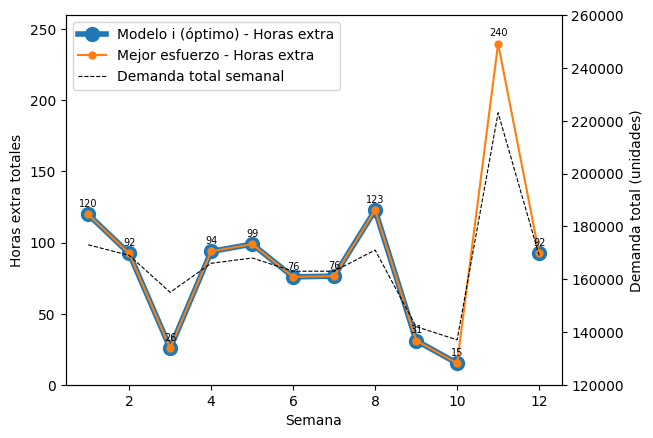

In [ ]:
# GRÁFICO: Horas extra vs Demanda

# Semanas
semanas = np.arange(1, 13)

# Horas extra - Modelo i (óptimo)
horas_extra_modelo_i = [
    119.76, 92.33, 25.71, 93.78, 98.91, 75.87,
    76.40, 122.78, 31.08, 15.11, None, 92.33
]

# Horas extra - Mejor esfuerzo
horas_extra_mejor_esfuerzo = [
    119.76, 92.33, 25.71, 93.78, 98.91, 75.87,
    76.40, 122.78, 31.08, 15.11, 240.00, 92.33
]

# Demanda total por semana
demanda_por_semana = [
    [35000, 30000, 40000, 40000, 28000],
    [30000, 28000, 40000, 43000, 28000],
    [30000, 20000, 40000, 35000, 30000],
    [30000, 30000, 40000, 38000, 28000],
    [30000, 30000, 40000, 40000, 28000],
    [35000, 25000, 40000, 38000, 25000],
    [35000, 25000, 38000, 40000, 25000],
    [33000, 34000, 37000, 42000, 25000],
    [33000, 34000, 0,     45000, 30000],
    [32000, 30000, 0,     45000, 30000],
    [45000, 40000, 50000, 50000, 38000],
    [30000, 28000, 40000, 43000, 28000]
]

demanda_total = [sum(semana) for semana in demanda_por_semana]

# Crear gráfico
fig, ax1 = plt.subplots()

# Línea azul (modelo i)
ax1.plot(semanas, horas_extra_modelo_i,
         marker='o',
         markersize=10,
         linewidth=4,
         label="Modelo i (óptimo) - Horas extra")

# Línea naranja (mejor esfuerzo)
ax1.plot(semanas, horas_extra_mejor_esfuerzo,
         marker='o', markersize=5,
         label="Mejor esfuerzo - Horas extra")

ax1.set_xlabel("Semana")
ax1.set_ylabel("Horas extra totales")
ax1.set_ylim(0, 260)

for x, y in zip(semanas, horas_extra_mejor_esfuerzo):
    ax1.annotate(f"{y:.0f}",
                 (x, y),
                 textcoords="offset points",
                 xytext=(0,4 ),
                 ha='center',
                 va='bottom',
                 fontsize=7)

# Línea de demanda
ax2 = ax1.twinx()
ax2.plot(semanas, demanda_total,
         color='black',linestyle='--', linewidth=0.8,
         label="Demanda total semanal")

ax2.set_ylim(120000, 260000)
ax2.set_ylabel("Demanda total (unidades)")



# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()


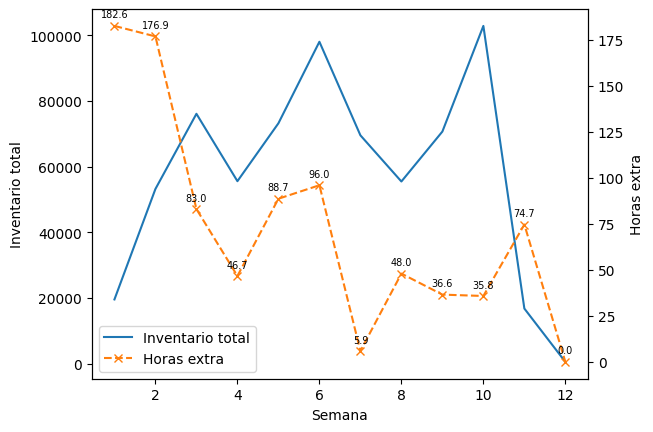

In [ ]:
# ------------------------------------------------------------
# Modelo ii – Inventario total vs horas extra
# - Leyenda abajo a la izquierda
# - Valores numéricos en los puntos
# ------------------------------------------------------------
semanas = np.arange(1, 13)

# Inventarios por pieza (modelo ii)
stock_P1 = [0, 0, 25700, 18800, 11900, 0, 14980, 20720, 10820, 1920, 6900, 0]
stock_P2 = [1930, 0, 0, 18700, 6850, 0, 15850, 0, 12750, 900, 9850, 0]
stock_P3 = [4000, 22500, 41000, 1000, 19500, 38000, 0, 3500, 3500, 50000, 0, 500]
stock_P4 = [0, 680, 9360, 15040, 18720, 24400, 28080, 1225, 43585, 50000, 0, 0]
stock_P5 = [13600, 30000, 0, 2000, 16200, 35600, 10600, 30000, 0, 0, 0, 0]

# Inventario total
inventario_total = (
    np.array(stock_P1)
    + np.array(stock_P2)
    + np.array(stock_P3)
    + np.array(stock_P4)
    + np.array(stock_P5)
)

# Horas extra
horas_extra = [182.57, 176.86, 83.05, 46.70, 88.67, 96.00,
               5.92, 48.00, 36.57, 35.83, 74.67, 0.00]

# Crear gráfico
fig, ax1 = plt.subplots()

# Línea inventario total
line1, = ax1.plot(semanas, inventario_total,
                  label="Inventario total")
ax1.set_xlabel("Semana")
ax1.set_ylabel("Inventario total")


# Segunda escala para horas extra
ax2 = ax1.twinx()

line2, = ax2.plot(semanas,
                  horas_extra,
                  linestyle='--',
                  marker='x',
                  color='tab:orange',
                  label="Horas extra")
ax2.set_ylabel("Horas extra")


for x, y in zip(semanas, horas_extra):
    ax2.annotate(f"{y:.1f}",
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 6),
                 ha='center',
                 fontsize=7)

#
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="lower left")

plt.show()


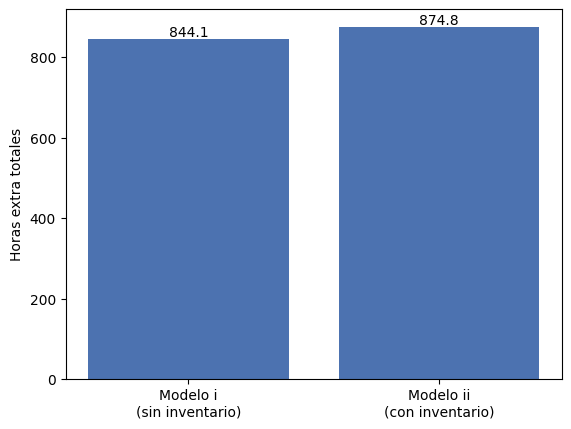

In [ ]:
modelos = ["Modelo i\n(sin inventario)", "Modelo ii\n(con inventario)"]
horas_extra_totales = [844.06, 874.84]

plt.figure()

bars = plt.bar(
    modelos,
    horas_extra_totales,
    color="#4C72B0"  # azul petróleo
)

plt.ylabel("Horas extra totales")

# Etiquetas de valor encima de las barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.show()



#pregunta iv

En esta pregunta no se busca maximizar la producción de forma directa, sino favorecer planes productivos continuos que minimicen los tiempos de preparación. Al permitir inventarios intersemanales y modelar la memoria de configuración de las máquinas, el modelo incentiva la producción prolongada de una misma pieza, incluso si ello implica generar inventarios temporales. De este modo, se reduce el número de cambios de molde, se incrementa el tiempo efectivo de producción y se disminuye la necesidad de horas extra

## iv.1 Parámetros modelo iv

Nuevo parámetro respecto a los otros modelos:

La información sobre continuidad de producción de una misma pieza en una

* máquina entre semanas (es decir, la posibilidad de mantener la máquina ya
preparada).

## iv.2 variables de decisión modelo iv

Nuevos parámetros respecto a los otros modelos:

* Las variables que modelan la continuidad de producción entre semanas y permiten eliminar o reducir el tiempo de preparación cuando no hay cambio de pieza.

 ## iv.3 Modelo de optimización iv: función objteivo y restricciones

 ## Función Objetivo modelo iv

 Minimizar total de horas extra:

 $$\min Z = \sum_{t=1}^{12} \sum_{m=1}^{5} o_{t,m}$$

 ## Restriciones que se mantienen de los modelos anteriores

## Balance de Inventario

para $t$=1

$$inv_{j1} = \sum_{i \in M_j} (h_{ij1} \cdot R_{i1} \cdot \eta_j) - D_{j1}$$

Para $t$ > 1
$$inv_{jt} = inv_{j, t-1} + \sum_{i \in M_j} (h_{ijt} \cdot R_{ij} \cdot \eta_j) - D_{jt}$$

## Restricción de capacidad por máquina

$$\sum_{j \in P_i} h_{ijt} + \sum_{j \in P_i} (y_{ijt} \cdot S_{ij}) \le 120 + o_{it}$$


## Activación de producción

$$h_{ij} \le (120 + 48) \cdot y_{ij}$$


## Nuevas restricciones

## Uso de la máquina esa semana

Se introduce una variable que indica si una máquina es utilizada en una semana determinada. Esta variable toma valor uno cuando la máquina produce al menos una pieza durante la semana y cero en caso contrario. Las restricciones asociadas garantizan la coherencia entre el uso de la máquina y la producción realizada, evitando que una máquina sea considerada activa si no produce nada o viceversa.

$$u_{it} \ge x_{ijt} $$

$$u_{it} \le \sum_{j \in P_i} x_{ijt} $$

$u_{it}$: 1 si la máquina $i$ se usa (produce algo) en semana $t$
$x_{ijt}$: 1 si se produce $j$ en la semana $t$

## Estado final de la máquina

Se establece que, al final de cada semana, cada máquina debe quedar configurada con exactamente un molde o estado asociado a una pieza, incluso si no se ha producido durante esa semana. Esta restricción permite definir de forma única el estado final de la máquina y es clave para modelar la continuidad entre semanas.

$$\sum_{j \in P_i} z_{ijt} =1$$


$z_{ijt}$:Variable binaria que indica si la máquina i termina la semana t configurada con el molde correspondiente a la pieza j.

## Consistencia del estado con la producción (solo si se usa la máquina)

Si la máquina se usa, el estado final debe corresponder a una pieza producida.
Si no se usa, puede mantener el estado anterior aunque no produzca.

$$\
z_{ijt} \le x_{ijt} + (1 - u_{it})
\$$

𝑢𝑖𝑡 : 1 si la máquina  𝑖  se usa (produce algo) en semana  𝑡   𝑥𝑖𝑗𝑡 : 1 si se produce  𝑗  en la semana  𝑡

$z_{ijt}$:Variable binaria que indica si la máquina i termina la semana t configurada con el molde correspondiente a la pieza j.

$x_{ij}$: Variable binaria que indica si la pieza j se produce en la máquina i durante la semana t.
Toma valor 1 si la máquina i produce la pieza j en la semana t, y 0 en caso contrario.

## Arrastre del estado (memoria real) si no se usa la máquina

Si una máquina no se usa en una semana, no se toca.
Por tanto, el molde con el que terminó la semana pasada sigue siendo el mismo.

$$z_{ijt} \ge z_{ij,t-1} - u_{it}
\qquad \forall i, j, t \ge 2\$$

## Setup intersemanal (warm start entre semanas)

El modelo permite reutilizar el estado final de una máquina de una semana a la siguiente, evitando pagar de nuevo el tiempo de preparación cuando se continúa produciendo la misma pieza. Esta restricción modela el efecto warm start y representa una mejora operativa respecto a los modelos anteriores.

$$y_{ij1} \ge 0$$
  
  
## No se paga setup si no se produce

se garantiza que el tiempo de preparación solo se contabiliza cuando existe producción
    
  $$y_{ijt} \le x_{ijt}$$

In [ ]:
# MODELO ii / PARTE 3: Integración intersemanal con inventario
# Objetivo: minimizar horas extra totales en 12 semanas


# 1) Definir el problema
prob = pulp.LpProblem("Falcon_Modelo_ii_Integrado", pulp.LpMinimize)

# 2) Variables
h   = pulp.LpVariable.dicts("Hrs",   [(t,m,p) for t in semanas for (m,p) in tasas.keys()], lowBound=0)
y   = pulp.LpVariable.dicts("Produce", [(t,m,p) for t in semanas for (m,p) in tasas.keys()], cat='Binary')
s   = pulp.LpVariable.dicts("Setup", [(t,m,p) for t in semanas for (m,p) in tasas.keys()], cat='Binary')
o   = pulp.LpVariable.dicts("Extra", [(t,m) for t in semanas for m in maquinas], lowBound=0, upBound=48)
inv = pulp.LpVariable.dicts("Stock", [(t,p) for t in semanas for p in piezas], lowBound=0)

# Estado final y uso de máquina (para setups intersemanales)
z = pulp.LpVariable.dicts("EstadoFinal", [(t,m,p) for t in semanas for (m,p) in tasas.keys()], cat='Binary')
u = pulp.LpVariable.dicts("Used", [(t,m) for t in semanas for m in maquinas], cat='Binary')

# 3) Función objetivo: minimizar horas extra totales
prob += pulp.lpSum(o[(t,m)] for t in semanas for m in maquinas)

# 4) Restricciones
for t in semanas:

    #  Balance inventario-demanda (por pieza)
    for p in piezas:
        # Producción buena de p en semana t
        prod_t_p = pulp.lpSum(
            h[(t,m,p)] * tasas[(m,p)] * rendimiento[p]
            for (m,p2) in tasas.keys() if p2 == p
        )

        demanda_t_p = demanda_por_semana[t-1][p-1]

        if t == 1:
            prob += inv[(t,p)] == prod_t_p - demanda_t_p
        else:
            prob += inv[(t,p)] == inv[(t-1,p)] + prod_t_p - demanda_t_p

        # inv >= 0 ya está en la definición → obliga a cumplir demanda globalmente con stock

    # Restricciones por máquina
    for m in maquinas:
        valid_p = [p_v for (m_v,p_v) in tasas.keys() if m_v == m]

        # Capacidad semanal: producción + setup <= 120 + extra
        prob += pulp.lpSum(
            h[(t,m,p)] + s[(t,m,p)] * setups[(m,p)]
            for p in valid_p
        ) <= 120 + o[(t,m)]

        # Definir u[t,m] (si produce algo)
        for p in valid_p:
            prob += u[(t,m)] >= y[(t,m,p)]
        prob += u[(t,m)] <= pulp.lpSum(y[(t,m,p)] for p in valid_p)

        # Link horas con binaria y (Big-M = 168)
        for p in valid_p:
            prob += h[(t,m,p)] <= 168 * y[(t,m,p)]

        # Estado final único por máquina
        prob += pulp.lpSum(z[(t,m,p)] for p in valid_p) == 1

        # Si se usa la máquina, el estado final debe ser una pieza producida esa semana
        for p in valid_p:
            prob += z[(t,m,p)] <= y[(t,m,p)] + (1 - u[(t,m)])

        # Si no se usa, mantener el estado anterior
        if t > 1:
            for p in valid_p:
                prob += z[(t,m,p)] - z[(t-1,m,p)] <= u[(t,m)]
                prob += z[(t-1,m,p)] - z[(t,m,p)] <= u[(t,m)]

        # Setup intersemanal:
        # desde semana 2: hay setup si produces p y no venías con p desde la semana anterior
        if t > 1:
            for p in valid_p:
                prob += s[(t,m,p)] >= y[(t,m,p)] - z[(t-1,m,p)]
        # semana 1: warm-start (no obligamos setup inicial)

# 5) Resolver
solver = pulp.PULP_CBC_CMD(timeLimit=100, gapRel=0.0, msg=0)
prob.solve(solver)

print(f"ESTADO: {pulp.LpStatus[prob.status]}")
print(f"Total horas extra: {pulp.value(prob.objective):.2f} horas")

estado_global = pulp.LpStatus[prob.status]
total = 0.0

print(f"{'Semana':<10} | {'Estado':<12} | {'Horas Extra Totales':<20}")
print("-"*55)

for t in semanas:
    he_t = sum(pulp.value(o[(t,m)]) for m in maquinas)
    he_t = 0.0 if he_t is None else float(he_t)
    total += he_t
    print(f"{t:<10} | {estado_global:<12} | {he_t:<20.2f}")

print("-"*55)
print(f"Total horas extra (todas las semanas): {total:.2f} horas")


ESTADO: Optimal
Total horas extra: 297.97 horas
Semana     | Estado       | Horas Extra Totales 
-------------------------------------------------------
1          | Optimal      | 84.73               
2          | Optimal      | 71.96               
3          | Optimal      | 49.21               
4          | Optimal      | 48.00               
5          | Optimal      | 6.94                
6          | Optimal      | 0.00                
7          | Optimal      | 0.00                
8          | Optimal      | 15.10               
9          | Optimal      | 0.00                
10         | Optimal      | 3.69                
11         | Optimal      | 13.33               
12         | Optimal      | 5.01                
-------------------------------------------------------
Total horas extra (todas las semanas): 297.97 horas


# Conclusiones

## Modelo i (planificación semanal sin inventario)

- Cada semana se optimiza de forma independiente, sin posibilidad de anticipar producción.

- En semanas de alta demanda se incrementa significativamente el uso de horas extra.

- En la semana 11 la demanda supera la capacidad máxima disponible (120h regulares + 48h extra por máquina), por lo que el modelo resulta inviable.

- El menor total de horas extra no implica mayor eficiencia, sino que refleja que el sistema no puede satisfacer completamente la demanda bajo estas restricciones.

## Modelo ii (planificación intersemanal con inventario)

- Se permite anticipar producción en semanas con menor carga y acumular inventario.

- El inventario actúa como reserva para absorber picos de demanda.

- La planificación intersemanal elimina la inviabilidad de la semana 11.

- El uso de horas extra se distribuye de forma más estable y controlada a lo largo del horizonte.

- El total de horas extra representa una solución factible y completa, garantizando el nivel de servicio.

## Comparación del modelo i y ii

- El modelo i es rígido y depende completamente de la demanda semanal.

- El modelo ii aumenta la flexibilidad operativa.

- El mayor uso total de horas extra en el modelo ii no representa ineficiencia, sino una planificación realista que asegura cumplimiento de la demanda.

- Desde una perspectiva operativa, permitir inventario mejora la estabilidad del sistema y reduce el riesgo de fallos por picos de capacidad.

## Modelo iii

- La mejora en el rendimiento (yield) incrementa la producción efectiva por hora trabajada.

- Se requieren menos horas totales para satisfacer una misma demanda.

- La capacidad efectiva del sistema aumenta sin necesidad de ampliar recursos físicos.


